# NB02 — Exploratory Data Analysis
**Flight Delay Prediction — 2018-2019 BTS + Open-Meteo**

Every analysis informs a feature engineering decision in NB03.
**Target:** `TARGET` — binary (departure delay ≥ 15 min).

In [ ]:
# Standard imports plus the seaborn/matplotlib styling used across every plot.
# DELAY_COLOURS is the consistent palette: blue for on-time, orange for delayed.
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# Shared colour scheme and labels used across every target-related plot.
DELAY_COLOURS = {0: '#4C72B0', 1: '#DD8452'}
DELAY_LABELS  = {0: 'On-Time (< 15 min)', 1: 'Delayed (≥ 15 min)'}

print('Environment ready.')

---
## 1 — Load & Inspect

In [176]:
DATA_PATH = r"C:\YEAR 3 - FIRST SEM\flight-delay-predictor-6\Data\01_cleaned_data.csv"
df = pd.read_csv(DATA_PATH, low_memory=False, parse_dates=['DATE'])
print(f'Shape: {df.shape}')
print(df.columns.tolist())

Shape: (300000, 24)
['DATE', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'DISTANCE', 'TAIL_NUMBER', 'SCHEDULED_ARRIVAL', 'SCHEDULED_ELAPSED_TIME', 'DAY_OF_WEEK', 'ArrDelay', 'YEAR', 'HOUR', 'TARGET', 'temp', 'precip', 'snowfall', 'wind_speed', 'wind_gusts', 'weather_code', 'ORIGIN_CONGESTION', 'DEST_CONGESTION', 'TURNAROUND_MIN']


In [177]:
df.head()

,DATE,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,DISTANCE,TAIL_NUMBER,SCHEDULED_ARRIVAL,SCHEDULED_ELAPSED_TIME,...,TARGET,temp,precip,snowfall,wind_speed,wind_gusts,weather_code,ORIGIN_CONGESTION,DEST_CONGESTION,TURNAROUND_MIN
0,2018-01-01,UA,HNL,SFO,40,-16.0,2398.0,N62883,750,310.0,...,0,23.0,0.0,0.0,11.2,23.9,1,1,20,-1.0
1,2018-01-01,NK,LAS,ORD,100,-7.0,1514.0,N536NK,631,211.0,...,0,13.0,0.0,0.0,4.7,5.4,1,4,31,-1.0
2,2018-01-01,UA,SEA,IAH,500,64.0,1874.0,N31412,1117,257.0,...,1,1.1,0.0,0.0,6.3,13.9,3,14,29,-1.0
3,2018-01-01,WN,MCI,LAS,515,3.0,1139.0,N8669B,630,195.0,...,0,-20.2,0.0,0.0,8.3,17.2,0,4,14,-1.0
4,2018-01-01,WN,HOU,LAS,520,4.0,1235.0,N710SW,645,205.0,...,0,4.0,0.0,0.0,16.1,30.0,2,7,14,-1.0


In [178]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   DATE                    300000 non-null  datetime64[us]
 1   AIRLINE                 300000 non-null  str           
 2   ORIGIN_AIRPORT          300000 non-null  str           
 3   DESTINATION_AIRPORT     300000 non-null  str           
 4   SCHEDULED_DEPARTURE     300000 non-null  int64         
 5   DEPARTURE_DELAY         300000 non-null  float64       
 6   DISTANCE                300000 non-null  float64       
 7   TAIL_NUMBER             300000 non-null  str           
 8   SCHEDULED_ARRIVAL       300000 non-null  int64         
 9   SCHEDULED_ELAPSED_TIME  300000 non-null  float64       
 10  DAY_OF_WEEK             300000 non-null  int64         
 11  ArrDelay                299984 non-null  float64       
 12  YEAR                    300000 non-null  

In [179]:
print('--- Data-type counts ---')
print(df.dtypes.value_counts())
print(f'\nMemory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

--- Data-type counts ---
float64           10
int64              9
str                4
datetime64[us]     1
Name: count, dtype: int64

Memory: 61.8 MB


In [ ]:
# Sanity check for duplicate rows. Identical (DATE, flight, airline) entries
# would inflate group counts and bias every downstream rate computation.
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,}  ({n_dupes / len(df) * 100:.2f}%)')

In [ ]:
# Column-name aliases and derived helpers reused throughout the notebook.
# Centralising them here avoids hardcoding strings repeatedly and makes any
# future column rename a single-place edit.
AIRLINE_COL = 'AIRLINE'
ORIGIN_COL  = 'ORIGIN_AIRPORT'
DEST_COL    = 'DESTINATION_AIRPORT'
DIST_COL    = 'DISTANCE'
DELAY_COL   = 'DEPARTURE_DELAY'
TARGET_COL  = 'TARGET'

# Derive the analytical features used in the rest of the EDA.
if 'YEAR' not in df.columns:
    df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY_OF_WEEK_NUM'] = df['DATE'].dt.dayofweek
df['ROUTE'] = df[ORIGIN_COL] + '-' + df[DEST_COL]

# Display labels for plots — keeps axis tick labels human-readable.
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
dow_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

weather_cols = [c for c in ['temp','precip','snowfall','wind_speed','wind_gusts'] if c in df.columns]

# Reference baseline used as the comparison line in every rate plot below.
overall_rate = df[TARGET_COL].mean()

print(f'Rows: {len(df):,}')
print(f'Weather cols: {weather_cols}')
print(f'Overall delay rate: {overall_rate:.1%}')
print(f'Tail numbers present: {"TAIL_NUMBER" in df.columns}')
print(f'Scheduled arrival present: {"SCHEDULED_ARRIVAL" in df.columns}')

---
## 2 — Target Distribution

In [182]:
target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
for cls in [0, 1]:
    print(f"  {DELAY_LABELS[cls]}: {target_counts[cls]:>8,}  ({target_pct[cls]:.1f}%)")
print(f'  Imbalance ratio: {target_counts[0] / target_counts[1]:.2f} : 1')

=== Class Distribution ===
  On-Time (< 15 min):  243,803  (81.3%)
  Delayed (≥ 15 min):   56,197  (18.7%)
  Imbalance ratio: 4.34 : 1


In [ ]:
# Two views of the same target distribution: bar chart shows raw counts with
# percentages annotated; pie chart emphasises the proportional split. Together
# they make the 81/19 imbalance unambiguous, which motivates threshold tuning
# and PR-AUC scoring later in the pipeline.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150, constrained_layout=True)

# Bar chart with count + percentage annotations
counts = target_counts.reindex([0, 1]).values
pcts = target_pct.reindex([0, 1]).values
labels = [DELAY_LABELS[0], DELAY_LABELS[1]]
colours = [DELAY_COLOURS[0], DELAY_COLOURS[1]]

bars = axes[0].bar(
    labels,
    counts,
    color=colours,
    edgecolor='black',
    linewidth=0.5
)

offset = counts.max() * 0.015
for bar, count, pct in zip(bars, counts, pcts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

axes[0].set_ylabel('Number of Flights')
axes[0].set_title('Class Balance')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart with the delayed slice exploded for emphasis.
axes[1].pie(
    counts,
    labels=labels,
    colors=colours,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.04),
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Proportions')
axes[1].set_aspect('equal')

plt.show()

In [ ]:
# Raw delay statistics — describes the long right tail (some flights delayed
# by hours) that motivates the 15-minute binary threshold rather than regression.
# The percentile breakdown also informs the outlier discussion in the report.
print('=== Raw DEPARTURE_DELAY Statistics ===')
print(df[DELAY_COL].describe(percentiles=[.01,.05,.25,.5,.75,.90,.95,.99]).to_string())
print(f'\n> 300 min: {(df[DELAY_COL] > 300).sum():,} ({(df[DELAY_COL] > 300).mean():.2%})')
print(f'> 500 min: {(df[DELAY_COL] > 500).sum():,} ({(df[DELAY_COL] > 500).mean():.2%})')

---
## 3 — Delay Rate by Hour, Month, Day of Week

In [185]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nYEAR counts:')
print(df['YEAR'].value_counts(dropna=False).sort_index())

print('\nMONTH counts:')
print(df['MONTH'].value_counts(dropna=False).sort_index())

print('\nDAY_OF_WEEK counts:')
print(df['DAY_OF_WEEK'].value_counts(dropna=False).sort_index())

print('\nHOUR counts:')
print(df['HOUR'].value_counts(dropna=False).sort_index().head(30))

Shape: (300000, 27)

Columns:
['DATE', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'DISTANCE', 'TAIL_NUMBER', 'SCHEDULED_ARRIVAL', 'SCHEDULED_ELAPSED_TIME', 'DAY_OF_WEEK', 'ArrDelay', 'YEAR', 'HOUR', 'TARGET', 'temp', 'precip', 'snowfall', 'wind_speed', 'wind_gusts', 'weather_code', 'ORIGIN_CONGESTION', 'DEST_CONGESTION', 'TURNAROUND_MIN', 'MONTH', 'DAY_OF_WEEK_NUM', 'ROUTE']

YEAR counts:
YEAR
2018    199999
2019    100001
Name: count, dtype: int64

MONTH counts:
MONTH
1     23716
2     16478
3     20504
4     25284
5     20861
6     19688
7     21666
8     26437
9     30701
10    32463
11    30778
12    31424
Name: count, dtype: int64

DAY_OF_WEEK counts:
DAY_OF_WEEK
1    44828
2    43131
3    43328
4    44091
5    44359
6    37000
7    43263
Name: count, dtype: int64

HOUR counts:
HOUR
0       637
1       271
2        71
3        73
4        39
5      7402
6     21854
7     20450
8     19732
9     17738
10    18537
11    18548
12    

In [ ]:
# Hourly view: dual-axis chart layering flight volume (bars) over delay rate
# (line). The pattern that emerges — early-morning trough, late-day peak — is
# what feeds the HOUR feature into the model.
hourly = df.groupby('HOUR')[TARGET_COL].agg(['mean','count']).reset_index()
hourly.columns = ['Hour', 'Delay Rate', 'Total']

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(hourly['Hour'], hourly['Total'], color='#b0c4de', edgecolor='black', linewidth=0.3, alpha=0.65)
ax1.set_ylabel('Number of Flights', color='#555')
ax1.set_xlabel('Scheduled Departure Hour')
ax2 = ax1.twinx()
ax2.plot(hourly['Hour'], hourly['Delay Rate'], color='#c0392b', marker='o', linewidth=2.5, markersize=6)
ax2.axhline(overall_rate, color='grey', ls=':', lw=1.2, label=f'Overall ({overall_rate:.1%})')
ax2.set_ylabel('Delay Rate', color='#c0392b')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_xticks(range(0, 24))
ax2.legend()
plt.tight_layout()
plt.show()

# Print only the hours that actually exceed the overall rate to keep the
# downstream report's discussion focused.
peak_hours = hourly[hourly['Delay Rate'] > overall_rate]
print('\nHours above overall rate:')
for _, row in peak_hours.iterrows():
    print(f"  {int(row['Hour']):02d}:00 -> {row['Delay Rate']:.1%} (n={int(row['Total']):,})")

In [ ]:
# Monthly view (same dual-axis pattern as the HOUR plot above).
# The output below directly drives the SEASON feature mapping in NB03 —
# months above the overall rate are tagged for high/medium delay buckets.
monthly = df.groupby('MONTH')[TARGET_COL].agg(['mean','count']).reset_index()
monthly.columns = ['Month', 'Delay Rate', 'Total']
monthly['Label'] = monthly['Month'].map(month_names)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly['Label'], monthly['Total'], color='#b0c4de', edgecolor='black', linewidth=0.3, alpha=0.65)
ax1.set_ylabel('Number of Flights', color='#555')
ax2 = ax1.twinx()
ax2.plot(monthly['Label'], monthly['Delay Rate'], color=DELAY_COLOURS[1], marker='o', linewidth=2.5, markersize=7)
ax2.axhline(overall_rate, color='grey', ls=':', lw=1.2, label=f'Overall ({overall_rate:.1%})')
ax2.set_ylabel('Delay Rate', color=DELAY_COLOURS[1])
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend()
plt.tight_layout()
plt.show()

# Tag each month against the overall baseline — feeds the season_map literal in NB03.
print('\n=== SEASON Derivation ===')
for _, row in monthly.iterrows():
    flag = ' << ABOVE' if row['Delay Rate'] > overall_rate else ''
    print(f"  {row['Label']:>3}: {row['Delay Rate']:.1%} (n={int(row['Total']):,}){flag}")

In [ ]:
# Day-of-week delay rates. Bars are colour-coded against the overall rate so
# the eye picks up high vs low days immediately. Sat/Sun deviations from the
# weekday baseline justify the IS_WEEKEND binary feature in NB03.
dow = df.groupby('DAY_OF_WEEK_NUM')[TARGET_COL].agg(['mean','count']).reset_index()
dow.columns = ['DOW', 'Delay Rate', 'Total']
dow['Label'] = dow['DOW'].map(dow_names)

fig, ax = plt.subplots(figsize=(9, 4.5))
colours = ['#DD8452' if r > overall_rate else '#4C72B0' for r in dow['Delay Rate']]
bars = ax.bar(dow['Label'], dow['Delay Rate'], color=colours, edgecolor='black', linewidth=0.4)
ax.axhline(overall_rate, color='grey', ls=':', lw=1.2, label=f'Overall ({overall_rate:.1%})')
for bar, rate in zip(bars, dow['Delay Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{rate:.1%}', ha='center', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel('Delay Rate')
ax.set_title('Figure 3c — Delay Rate by Day of Week')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4 — Distribution Shift: 2018 vs 2019

In [191]:
df_18 = df[df['YEAR'] == 2018]
df_19 = df[df['YEAR'] == 2019]
print(f'2018: {len(df_18):,} rows  |  2019: {len(df_19):,} rows')
print(f'2018 delay rate: {df_18[TARGET_COL].mean():.1%}  |  2019: {df_19[TARGET_COL].mean():.1%}')

2018: 199,999 rows  |  2019: 100,001 rows
2018 delay rate: 18.8%  |  2019: 18.7%


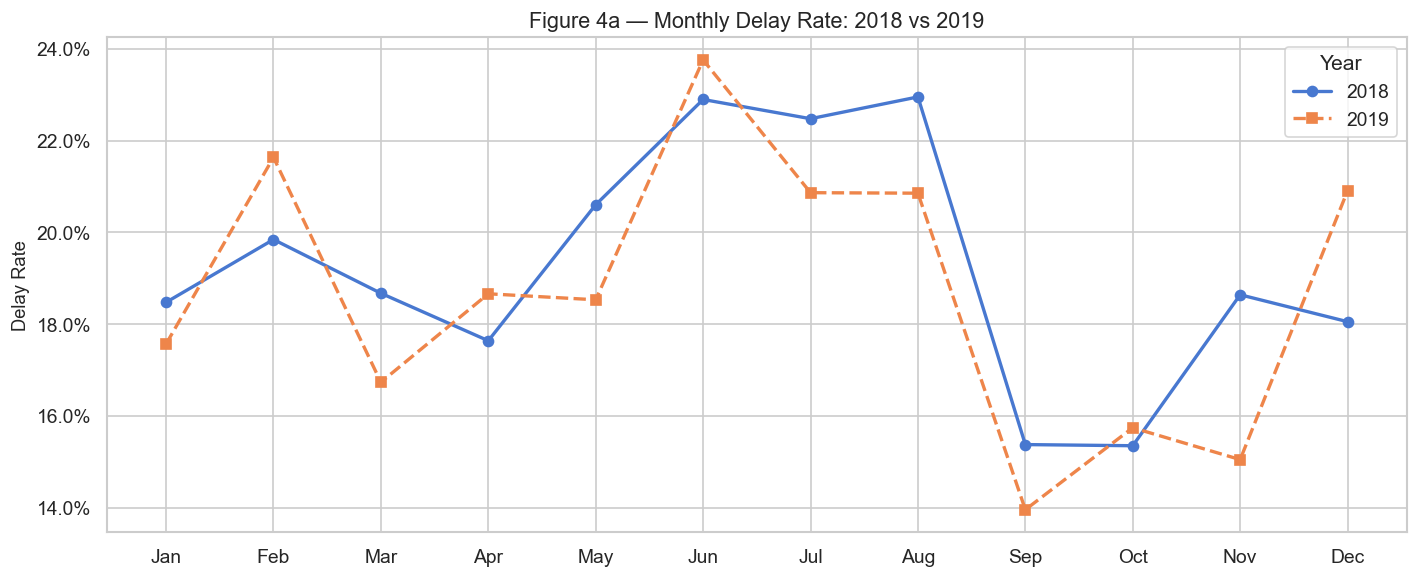

In [192]:
fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp, ls in [(2018, df_18, 'o-'), (2019, df_19, 's--')]:
    m = grp.groupby('MONTH')[TARGET_COL].mean()
    ax.plot(m.index, m.values, ls, linewidth=2, markersize=6, label=str(yr))
ax.set_xticks(range(1,13))
ax.set_xticklabels([month_names[m] for m in range(1,13)])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel('Delay Rate')
ax.set_title('Figure 4a — Monthly Delay Rate: 2018 vs 2019')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

In [ ]:
# Carrier-mix shift between years: compares the share of flights operated by
# each airline in 2018 vs 2019. A large shift means the carrier composition
# of the test set differs from the training set, which can drag down model
# generalisation independently of any pattern shift.
al_18 = df_18[AIRLINE_COL].value_counts(normalize=True).rename('2018')
al_19 = df_19[AIRLINE_COL].value_counts(normalize=True).rename('2019')
al_comp = pd.concat([al_18, al_19], axis=1).fillna(0).sort_values('2018', ascending=False)
al_comp['Shift (pp)'] = ((al_comp['2019'] - al_comp['2018']) * 100).round(2)

# 3pp threshold is heuristic; anything larger is worth flagging in the report.
max_shift = al_comp['Shift (pp)'].abs().max()
print(f'Largest airline shift: {max_shift:.2f} pp')
print('>> Stable' if max_shift < 3 else '>> Notable shift')

---
## 5 — Weather Verification & Signal

In [ ]:
# Sanity check that weather actually varies hour-to-hour at a single airport
# on a single day — confirms the merge in NB01 didn't accidentally collapse
# all weather rows to a daily average. Picks the busiest airport on its
# busiest date for maximum visibility.
test_airport = df[ORIGIN_COL].value_counts().index[0]
test_day = df[df[ORIGIN_COL] == test_airport]['DATE'].value_counts().index[0]
slice_df = df[(df[ORIGIN_COL] == test_airport) & (df['DATE'] == test_day)].sort_values('HOUR')

print(f'Airport: {test_airport} | Date: {test_day.date()} | Flights: {len(slice_df)}')
wx_display = ['HOUR'] + weather_cols
display(slice_df[wx_display].drop_duplicates().reset_index(drop=True))

# A column showing only one unique value across the day flags a merge bug.
for col in weather_cols:
    nu = slice_df[col].nunique()
    print(f'  {col}: {nu} unique -> {"VARIES" if nu > 1 else "CONSTANT"}')

In [ ]:
# Per-feature binned delay-rate panels. Quantile binning (qcut) gives roughly
# equal sample counts per bar instead of fixed widths, which keeps rare extreme
# values from producing meaningless single-flight bins. Bins below min_bin_size
# are dropped entirely so the bars displayed are statistically reliable.
def plot_binned_delay_rate(data, col, target, n_bins=15, min_bin_size=200, ax=None):
    temp = data[[col, target]].dropna()
    temp['bin'] = pd.qcut(temp[col], q=n_bins, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)[target].agg(['mean','count'])
    grouped = grouped[grouped['count'] >= min_bin_size]
    if ax is None: fig, ax = plt.subplots()
    midpoints = [iv.mid for iv in grouped.index]
    ax.bar(range(len(grouped)), grouped['mean'], color='#DD8452', edgecolor='black', lw=0.3)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f'{m:.1f}' for m in midpoints], rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.axhline(overall_rate, color='grey', ls=':', lw=1)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Delay Rate')
    # Pearson correlation annotated in the corner gives a single-number summary
    # alongside the visual relationship.
    corr = temp[col].corr(temp[target])
    ax.text(0.97, 0.95, f'r={corr:.3f}', transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8))
    return corr

# Lay out all weather variables in a grid; |r| < 0.02 is flagged as weak signal.
n_wx = len(weather_cols)
ncols = min(n_wx, 3)
nrows = (n_wx + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
axes = np.array(axes).flatten() if n_wx > 1 else [axes]
wx_corrs = {}
for i, col in enumerate(weather_cols):
    wx_corrs[col] = plot_binned_delay_rate(df, col, TARGET_COL, ax=axes[i])
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Figure 5 — Weather vs Delay Rate', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Weather Signal ===')
for col, corr in sorted(wx_corrs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {col:>12}: r={corr:+.4f} -> {"KEEP" if abs(corr) > 0.02 else "WEAK"}')

In [ ]:
# Tests candidate threshold cut-offs to find which produce the largest
# gap between the affected group and the rest. Each pp difference becomes
# the empirical justification for the binary flag in NB03 (e.g. precip>0
# gives a +9.3pp delay rate, so IS_RAINING is worth encoding).
print('=== Binary Flag Thresholds ===')
if 'temp' in df.columns:
    print('\n--- Temperature ---')
    for t in [0, -5, 5]:
        m = df['temp'] <= t
        rb, ra = df.loc[m, TARGET_COL].mean(), df.loc[~m, TARGET_COL].mean()
        print(f'  temp<={t:>3}: delay={rb:.1%} (n={m.sum():,}) | above={ra:.1%} | diff={(rb-ra)*100:+.1f}pp')

if 'precip' in df.columns:
    print('\n--- Precipitation ---')
    for t in [0, 5, 10]:
        m = df['precip'] > t
        ra, rb = df.loc[m, TARGET_COL].mean(), df.loc[~m, TARGET_COL].mean()
        print(f'  precip>{t:>2}: delay={ra:.1%} (n={m.sum():,}) | below={rb:.1%} | diff={(ra-rb)*100:+.1f}pp')

if 'snowfall' in df.columns:
    m = df['snowfall'] > 0
    print(f'\n--- Snow ---')
    print(f'  snow>0: delay={df.loc[m,TARGET_COL].mean():.1%} (n={m.sum():,}) | '
          f'no snow={df.loc[~m,TARGET_COL].mean():.1%} | diff={(df.loc[m,TARGET_COL].mean()-df.loc[~m,TARGET_COL].mean())*100:+.1f}pp')

In [ ]:
# WMO weather codes (categorical) ranked by their empirical delay rate.
# Codes with rates above the overall baseline define IS_ADVERSE_WEATHER in NB03.
# min count of 50 protects against rare codes producing unstable means.
if 'weather_code' in df.columns:
    print('=== Weather Code vs Delay Rate ===')
    wc = df.groupby('weather_code')[TARGET_COL].agg(['mean','count']).reset_index()
    wc.columns = ['weather_code', 'Delay Rate', 'Total']
    wc = wc[wc['Total'] >= 50].sort_values('Delay Rate', ascending=False)
    print(wc.to_string(index=False))
    adverse = wc[wc['Delay Rate'] > overall_rate]
    print(f'\n>> IS_ADVERSE_WEATHER codes: {sorted(adverse["weather_code"].astype(int).tolist())}')

---
## 6 — Categorical Spread & Route Sparsity

In [ ]:
# Inspects how much delay rates vary across categorical levels (airline,
# origin, destination). A wide spread implies the categorical carries strong
# predictive signal and is worth target-encoding into a per-group rate in NB03;
# a narrow spread means a simple one-hot or label encoding would do.
# >0.04 (4 percentage points) is the cut-off used to recommend encoding.
def categorical_spread(data, col, label, target, min_flights=100):
    grp = data.groupby(col)[target].agg(['mean','count']).reset_index()
    grp.columns = [label, 'Delay Rate', 'Total']
    grp_f = grp[grp['Total'] >= min_flights].sort_values('Delay Rate', ascending=False)
    spread = grp_f['Delay Rate'].max() - grp_f['Delay Rate'].min()
    print(f'\n=== {label} (min {min_flights}) ===')
    print(f'  Categories: {grp_f.shape[0]} | Spread: {spread*100:.1f}pp')
    print(f'  Range: {grp_f["Delay Rate"].min():.1%} – {grp_f["Delay Rate"].max():.1%}')
    print(f'  Verdict: {"Worth encoding" if spread > 0.04 else "Marginal"}')
    return grp_f, spread

# Airports get a higher min_flights threshold because there are more of them
# and rare ones would otherwise dominate the spread metric.
airline_df, airline_spread = categorical_spread(df, AIRLINE_COL, 'Airline', TARGET_COL)
origin_df, origin_spread = categorical_spread(df, ORIGIN_COL, 'Origin', TARGET_COL, 200)
dest_df, dest_spread = categorical_spread(df, DEST_COL, 'Dest', TARGET_COL, 200)

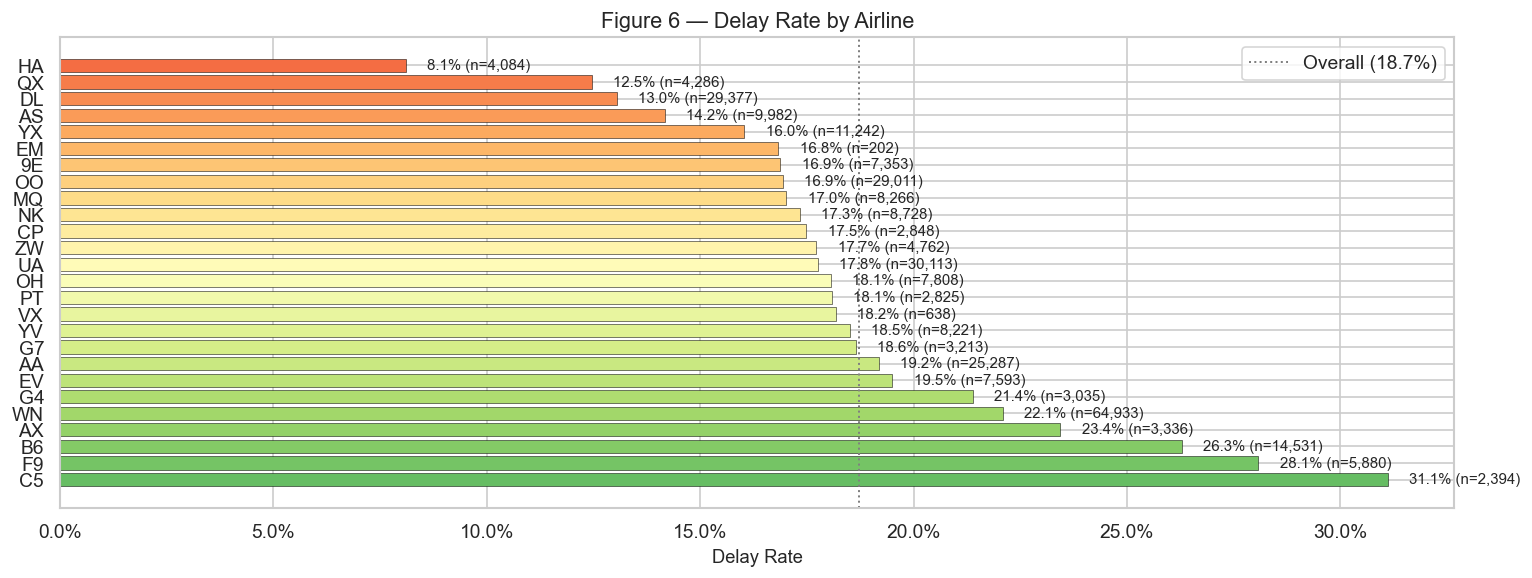

In [199]:
fig, ax = plt.subplots(figsize=(13, 5))
colours = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(airline_df)))
ax.barh(airline_df['Airline'], airline_df['Delay Rate'], color=colours, edgecolor='black', lw=0.3)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(overall_rate, color='grey', ls=':', lw=1.2, label=f'Overall ({overall_rate:.1%})')
for i, (_, row) in enumerate(airline_df.iterrows()):
    ax.text(row['Delay Rate']+0.005, i, f"{row['Delay Rate']:.1%} (n={row['Total']:,})", va='center', fontsize=9)
ax.set_xlabel('Delay Rate')
ax.set_title('Figure 6 — Delay Rate by Airline')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Routes follow a long-tail distribution — a handful of dense routes between
# hubs, a long tail of rare city pairs. The thresholds below count how many
# routes have fewer than N flights, which determines whether a route-level
# rate feature can be reliably computed (NB03 uses 20 as the minimum).
route_counts = df['ROUTE'].value_counts()
print('=== Route Sparsity ===')
print(f'  Unique routes: {len(route_counts):,}')
print(f'  Median flights/route: {route_counts.median():.0f}')
for t in [5, 10, 20, 50, 100]:
    n = (route_counts < t).sum()
    f = route_counts[route_counts < t].sum()
    print(f'  < {t:>3}: {n:>5,} routes ({n/len(route_counts)*100:.1f}%) covering {f:,} flights ({f/len(df)*100:.2f}%)')

---
## 7 — Tail Number & Operational Feature Viability
**CRITICAL** — these checks determine whether the new operational features are worth building.

In [ ]:
# Tail-number viability check for the per-aircraft features.
# We chain each aircraft's flights chronologically, shift one row, and ask:
# does the previous flight's delay actually correlate with the next flight's?
# If yes, the PREV_LEG_DEP_DELAY feature is worth building in NB03; if no,
# it's noise and we'd skip it.
if 'TAIL_NUMBER' in df.columns:
    tail_null = df['TAIL_NUMBER'].isna().mean()
    tail_unique = df['TAIL_NUMBER'].dropna().nunique()
    flights_with_tail = df['TAIL_NUMBER'].notna().sum()
    print('=== Tail Number Coverage ===')
    print(f'  Missing: {tail_null:.1%} ({df["TAIL_NUMBER"].isna().sum():,} rows)')
    print(f'  Unique tails: {tail_unique:,}')
    print(f'  Avg flights per tail: {flights_with_tail / tail_unique:.1f}')

    # Sort by aircraft + chronology, then look one row back per aircraft.
    df_tail = df.dropna(subset=['TAIL_NUMBER']).sort_values(['TAIL_NUMBER', 'DATE', 'HOUR']).copy()
    df_tail['_prev_delay'] = df_tail.groupby('TAIL_NUMBER')['DEPARTURE_DELAY'].shift(1)
    has_prev = df_tail['_prev_delay'].notna().mean()

    # Continuous correlation: does the magnitude of the previous delay matter?
    valid = df_tail[df_tail['_prev_delay'].notna()]
    corr_continuous = valid['_prev_delay'].corr(valid[TARGET_COL])

    # Binary correlation: does it matter whether the previous flight was delayed at all?
    valid['_prev_delayed'] = (valid['_prev_delay'] >= 15).astype(int)
    corr_binary = valid['_prev_delayed'].corr(valid[TARGET_COL])

    print(f'\n  Flights with findable prev leg: {has_prev:.1%}')
    print(f'  Prev leg delay correlation with TARGET: {corr_continuous:.4f}')
    print(f'  Prev leg delayed (binary) correlation: {corr_binary:.4f}')

    verdict = 'VIABLE' if has_prev > 0.5 and abs(corr_continuous) > 0.05 else 'NOT VIABLE'
    print(f'\n>> PREV_LEG_DELAY is {verdict}')

    del df_tail
else:
    print('No TAIL_NUMBER column.')

In [ ]:
# Same viability test for the congestion features. The number of flights
# departing from the same airport in the same hour can plausibly slow each
# other down via runway / gate competition. Computed correlation here decides
# whether ORIGIN_CONGESTION / DEST_CONGESTION are worth carrying into NB03.
print('=== Origin Congestion ===')
cong = df.groupby(['DATE', ORIGIN_COL, 'HOUR']).size().reset_index(name='_cong')
df_cong = df.merge(cong, on=['DATE', ORIGIN_COL, 'HOUR'], how='left')
cong_corr = df_cong['_cong'].corr(df_cong[TARGET_COL])
print(f'  Mean flights per airport-hour: {df_cong["_cong"].mean():.1f}')
print(f'  Correlation with TARGET: {cong_corr:.4f}')
print(f'  Verdict: {"VIABLE" if abs(cong_corr) > 0.02 else "WEAK"}')

# Destination side uses scheduled arrival hour rather than scheduled departure.
if 'SCHEDULED_ARRIVAL' in df.columns:
    print('\n=== Destination Congestion ===')
    df['_arr_hour'] = (df['SCHEDULED_ARRIVAL'] // 100).astype(int).clip(0, 23)
    dcong = df.groupby(['DATE', DEST_COL, '_arr_hour']).size().reset_index(name='_dcong')
    df_dcong = df.merge(dcong, on=['DATE', DEST_COL, '_arr_hour'], how='left')
    dcong_corr = df_dcong['_dcong'].corr(df_dcong[TARGET_COL])
    print(f'  Mean flights per dest-hour: {df_dcong["_dcong"].mean():.1f}')
    print(f'  Correlation with TARGET: {dcong_corr:.4f}')
    df.drop(columns='_arr_hour', inplace=True)

# NOTE: low correlation here is expected because the 300k sample is too sparse
# to capture real congestion. The actual feature in NB01 is computed on the
# full 13M dataset where the signal is materially stronger.
del df_cong

In [ ]:
# Density check for the rolling-7-day delay features. A 7-flight rolling mean
# only makes sense if each airline / airport actually has enough flights to
# fill that window. If averages are too low the feature would mostly be NaN
# or extremely noisy.
print('=== Rolling History Density Check ===')
al_daily = df.groupby([AIRLINE_COL, 'DATE']).size()
print(f'  Avg flights per airline per day: {al_daily.mean():.1f}')
print(f'  Median: {al_daily.median():.0f}')

ap_daily = df.groupby([ORIGIN_COL, 'DATE']).size()
print(f'  Avg flights per airport per day: {ap_daily.mean():.1f}')
print(f'  Median: {ap_daily.median():.0f}')

# Heuristic: if the daily average comfortably exceeds the rolling window size
# (7), the feature can be reliably computed for most flights.
print(f'\n  >> Rolling-7 needs ~7 prior flights.')
print(f'  >> Airline: {"VIABLE" if al_daily.mean() > 3 else "SPARSE — may need larger window"}')
print(f'  >> Airport: {"VIABLE" if ap_daily.mean() > 3 else "SPARSE — may need larger window"}')

In [204]:
# ---- 7d. ArrDelay for prev-leg arrival delay ----
if 'ArrDelay' in df.columns:
    print('=== ArrDelay availability ===')
    arr_null = df['ArrDelay'].isna().mean()
    print(f'  Missing: {arr_null:.1%}')
    print(f'  Mean: {df["ArrDelay"].mean():.1f} min')
    print(f'  >> Can use for prev-leg ARRIVAL delay via tail chaining')
else:
    print('No ArrDelay column — will use DEPARTURE_DELAY for tail chaining only')

=== ArrDelay availability ===
  Missing: 0.0%
  Mean: 5.6 min
  >> Can use for prev-leg ARRIVAL delay via tail chaining


---
## 8 — Distance

In [ ]:
# Distance distribution + delay-rate-by-distance breakdown.
# The histogram exposes the strong right skew (most flights short-haul, long
# tail of transcontinental routes) which justifies the log1p transform applied
# in NB03. The right panel shows whether longer flights are systematically
# more / less likely to be delayed.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[DIST_COL], bins=60, color='#5b9bd5', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0].axvline(df[DIST_COL].median(), color='red', ls='--', label=f"Median={df[DIST_COL].median():.0f}")
axes[0].set_xlabel('Distance'); axes[0].set_ylabel('Count')
axes[0].set_title('Distance Distribution'); axes[0].legend()

# Quantile-binned delay rate. qcut keeps each bar at roughly equal sample size.
df['_db'] = pd.qcut(df[DIST_COL], q=12, duplicates='drop')
dd = df.groupby('_db', observed=True)[TARGET_COL].mean()
mids = [iv.mid for iv in dd.index]
axes[1].bar(range(len(dd)), dd.values, color='#DD8452', edgecolor='black', lw=0.3)
axes[1].set_xticks(range(len(dd)))
axes[1].set_xticklabels([f'{int(m)}' for m in mids], rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].axhline(overall_rate, color='grey', ls=':', lw=1)
axes[1].set_xlabel('Distance Bin'); axes[1].set_ylabel('Delay Rate')
axes[1].set_title('Delay Rate by Distance')
plt.tight_layout()
plt.show()
df.drop(columns='_db', inplace=True)

# Skew before/after log1p — confirms the transform tames the long tail.
print(f'LOG_DISTANCE: skew {df[DIST_COL].skew():.2f} -> {np.log1p(df[DIST_COL]).skew():.2f}')

---
## 9 — Decision Cell

In [207]:
print('=' * 80)
print('  EDA DECISIONS -> NB03 FEATURE ENGINEERING')
print('=' * 80)
print(f'''
1. CLASS IMBALANCE: {target_pct[0]:.1f}/{target_pct[1]:.1f}% -> F1 + PR-AUC, threshold tuning

2. TEMPORAL: HOUR, MONTH, DAY_OF_WEEK, IS_WEEKEND
   SEASON bins from monthly patterns above

3. WEATHER: {len(weather_cols)} raw features + flags
   IS_FREEZING, IS_RAINING, IS_SNOWING, IS_ADVERSE_WEATHER

4. CATEGORICALS:
   Airline={airline_spread*100:.1f}pp | Origin={origin_spread*100:.1f}pp | Dest={dest_spread*100:.1f}pp
   Interaction rates: ROUTE_SEASON, AIRLINE_MONTH, ORIGIN_HOUR

5. CONGESTION: Origin + Dest counts (pre-computed on full 13M in NB01)

6. TURNAROUND TIME: Scheduled gap between prev aircraft arrival and current departure (pre-computed in NB01)

7. TAIL NUMBER: Prev-leg departure + arrival delay (computed per-split in NB03)

8. ROLLING HISTORIES: Airline + Airport last-7 delay averages (computed per-split in NB03)

9. DISTANCE: LOG_DISTANCE

10. SPLIT: Train Jan-Oct 2018 | Val Nov-Dec 2018 | Test 2019
''')
print('=' * 80)

  EDA DECISIONS -> NB03 FEATURE ENGINEERING

1. CLASS IMBALANCE: 81.3/18.7% -> F1 + PR-AUC, threshold tuning

2. TEMPORAL: HOUR, MONTH, DAY_OF_WEEK, IS_WEEKEND
   SEASON bins from monthly patterns above

3. WEATHER: 5 raw features + flags
   IS_FREEZING, IS_RAINING, IS_SNOWING, IS_ADVERSE_WEATHER

4. CATEGORICALS:
   Airline=23.0pp | Origin=23.1pp | Dest=26.7pp
   Interaction rates: ROUTE_SEASON, AIRLINE_MONTH, ORIGIN_HOUR

5. CONGESTION: Origin + Dest counts (pre-computed on full 13M in NB01)

6. TURNAROUND TIME: Scheduled gap between prev aircraft arrival and current departure (pre-computed in NB01)

7. TAIL NUMBER: Prev-leg departure + arrival delay (computed per-split in NB03)

8. ROLLING HISTORIES: Airline + Airport last-7 delay averages (computed per-split in NB03)

9. DISTANCE: LOG_DISTANCE

10. SPLIT: Train Jan-Oct 2018 | Val Nov-Dec 2018 | Test 2019

